# CPM profiles at boundaries near centromeres vs on arms

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import bioframe as bf
import bbi

from functools import partial
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map

from pathlib import Path

In [2]:
sns.set_context('talk')

## Load boundaries and centromeres

In [3]:
BOUNDARIES_PATH = '/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_annot/boundaries.parquet'

In [4]:
boundaries = pd.read_parquet(BOUNDARIES_PATH)

In [5]:
boundaries.shape[0]

13257

In [6]:
hg19_cens = bf.fetch_centromeres('hg19', provider='local')

In [7]:
bf.overlap(boundaries, hg19_cens, how='inner').shape[0]

63

There are 63 boundaries within these coordinates!

## Make near-centromeric regions

In [8]:
PAD = 10_000_000

In [9]:
near_cens_df = bf.expand(hg19_cens, pad=PAD)

## Annotate boundaries near centromeres

In [10]:
def annotate_overlap_feature(region_df, feature_df, name):
    overlap_idx = bf.overlap(region_df, feature_df, return_input=False, return_index=True)
    overlap_idx[name] = overlap_idx['index_'].map(lambda x: not pd.isna(x))
    overlap_status = overlap_idx.groupby('index')[name].apply(np.any)
    region_df[name] = overlap_status

In [11]:
NAME = 'near_cens'

In [12]:
annotate_overlap_feature(boundaries, near_cens_df, NAME)

In [13]:
boundaries[NAME].value_counts()

False    11559
True      1698
Name: near_cens, dtype: int64

Around 10% of boundaries are in 10Mb radius around centromeres.

## ChIP-seq signals

In [14]:
TRACKS_DIR = Path('/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/')
track_paths = {'Sororin': TRACKS_DIR / 'Sororin/WT_G2/Sororin_WT_G2.chip.bw',
               'RAD21': TRACKS_DIR / 'RAD21/WT_G2/RAD21_WT_G2.chip.bw'}

In [15]:
CN_PATH = '/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/copy_numbers/cnv_seg.bw'

### Estimate averages with new resolution

In [16]:
chromsizes = bf.fetch_chromsizes('hg19')

In [17]:
copy_numbers_vecs = {chrom: bbi.fetch(CN_PATH, chrom, 0, size, bins=size // 1_000, missing=np.nan)
                     for chrom, size in chromsizes.items() if chrom not in ('chrY', 'chrM')}

In [18]:
def get_binned_mean(track, chromsizes, binsize):
    chrom_means = list()
    for chrom, size in chromsizes.items():
        if chrom in ('chrY', 'chrM'):
            continue
        vec = bbi.fetch(str(track), chrom, 0, size, bins=size//binsize, missing=np.nan)
        norm_vec = vec / copy_numbers_vecs[chrom]
        norm_vec[np.isinf(norm_vec)] = np.nan
        chrom_means.append(np.nanmean(norm_vec))
    return np.nanmean(chrom_means)

In [19]:
gw_means = dict()
for protein, path in tqdm(track_paths.items()):
    new_mean = get_binned_mean(path, chromsizes, 1_000)
    gw_means[protein] = new_mean

  0%|          | 0/2 [00:00<?, ?it/s]

In [20]:
gw_means

{'Sororin': 0.033853500467369214, 'RAD21': 0.0310693479064608}

### Extraction functions

In [21]:
def _extract_signal_chunk(df, path, bins=-1, summary='mean', missing=0):
    with bbi.open(path) as f:
        hmap = f.stackup(df['chrom'], df['start'], df['end'], bins=bins, summary=summary, missing=missing)
    return hmap


def extract_signal(df, path, bins=-1, summary='mean', missing=0, chunks=1, cores=1):
    df_chuncks = np.array_split(df, chunks)
    func = partial(_extract_signal_chunk, path=str(path), bins=bins, summary=summary, missing=missing)
    results = process_map(func, df_chuncks, max_workers=cores, desc='chunk')
    return np.concatenate(results)

### Create windows

I want to create TAD boundary +- 100Kb.

In [22]:
midpoints = (boundaries['start'] + boundaries['end']) // 2

In [23]:
windows = pd.DataFrame({'chrom': boundaries['chrom'],
                        'start': midpoints - 100_000,
                        'end': midpoints + 100_000})

### Get signals

I want to get 1Kb resolution -> 201 bins for +-100Kb.

In [24]:
BINS = 201

In [25]:
copy_numbers_hmap = extract_signal(windows, CN_PATH, bins=BINS, missing=np.nan, chunks=100, cores=8)
copy_numbers_hmap[copy_numbers_hmap == 0] = np.nan

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

In [26]:
heatmaps = dict()
for protein, path in track_paths.items():
    signal = extract_signal(windows, path, bins=BINS, missing=np.nan, chunks=100, cores=8)
    norm_signal = signal / copy_numbers_hmap
    heatmaps[protein] = norm_signal

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

chunk:   0%|          | 0/100 [00:00<?, ?it/s]

## Make average plots

In [27]:
condition_palettes = {'Sororin': 'darkred',
                      'RAD21': 'darkblue'}

In [28]:
alpha_levels = {'high': 1,
                'med': .7,
                'low': .4}

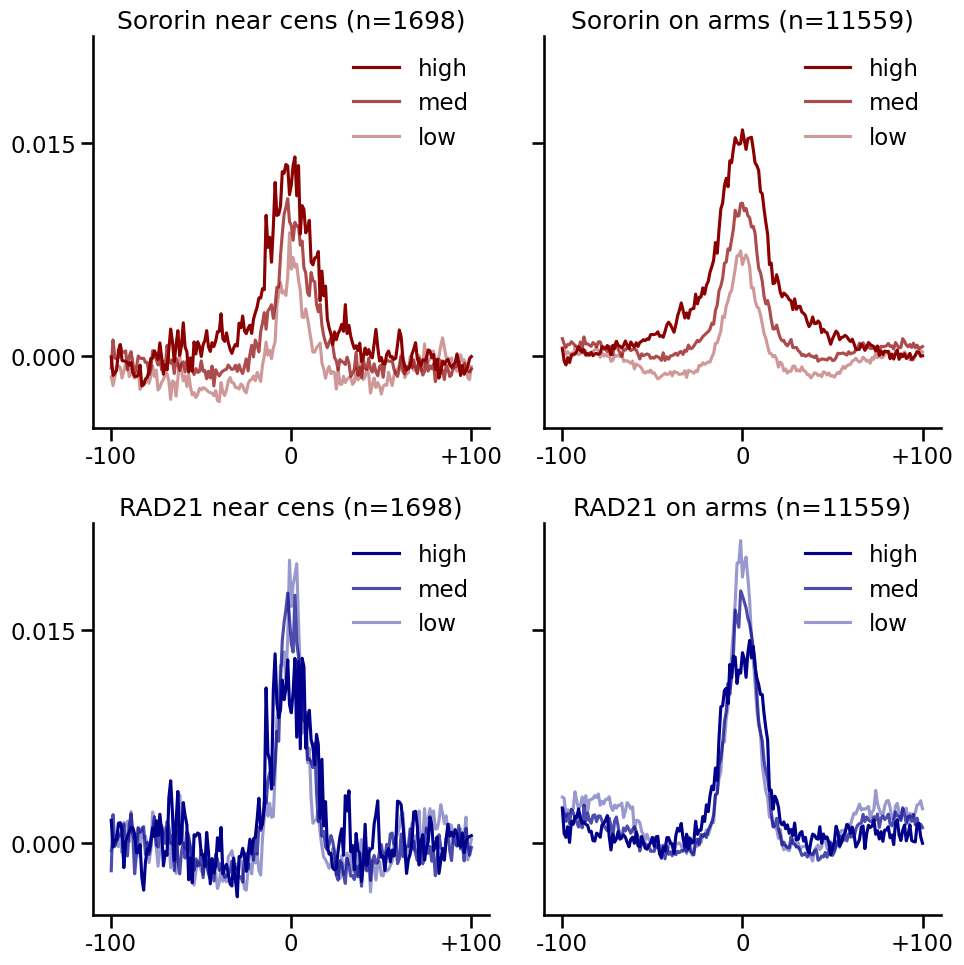

In [29]:
with sns.plotting_context('talk'):
    fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=100, sharey=True)
    for row_idx, (protein, hmap) in enumerate(heatmaps.items()):
        for col_idx, status in enumerate((True, False)):
            plt.sca(axes[row_idx, col_idx])
            boundaries_status = boundaries.query(f"{NAME} == {status}")
            for title, df in boundaries_status.groupby('levelGroup'):
                idx = df.index
                profile = np.nanmean(hmap[idx, :], axis=0)
                norm_profile = profile - gw_means[protein]
                plt.plot(norm_profile,
                         label=title,
                         color=condition_palettes[protein],
                         zorder=3,
                         alpha=alpha_levels[title])
            plt.legend(edgecolor='none')
            plt.xticks([0, 100, 200], ['-100', '0', '+100'])
            plt.gca().yaxis.set_major_locator(plt.MaxNLocator(2))
            if status:
                location = 'near cens'
            else:
                location = 'on arms'
            plt.title(f"{protein} {location} (n={boundaries_status.shape[0]})")
            sns.despine()
    plt.tight_layout()